## Chargement des données

In [1]:
import pandas as pd

# Charger le fichier Feather
df = pd.read_feather("data_indian_ocean.feather")

# Afficher les 5 premières lignes
print(df.head())

print(df)

print("Latitude maximale :", df["latitude"].min())

       imo       mmsi          name   latitude  longitude  \
0  7361922  538003805  GOLAR FREEZE  25.031168  55.067681   
1  7361922  538003805  GOLAR FREEZE  25.031168  55.067828   
2  7361922  538003805  GOLAR FREEZE  25.031168  55.067757   
3  7361922  538003805  GOLAR FREEZE  25.031168  55.067830   
4  7361922  538003805  GOLAR FREEZE  25.031168  55.067745   

                    timestamp  sog         cog nav status  nav status code  \
0  2015-01-01T01:46:03.000000  0.0  248.059574     Moored                5   
1  2015-01-01T02:46:03.000000  0.0  319.248561     Moored                5   
2  2015-01-01T03:46:03.000000  0.0   87.004785     Moored                5   
3  2015-01-01T04:46:03.000000  0.0  187.692308     Moored                5   
4  2015-01-01T05:46:03.000000  0.0  296.457627     Moored                5   

   ...  at port  port stay type wave period Tp (s)  \
0  ...     True        dry dock           6.106798   
1  ...     True        dry dock           6.080306   
2 

## Tirer un sample aléatoire du dataframe initial

In [5]:
print(len(df))

df_sample = df.sample(n=500000, random_state=42)

13736058


## Affichage de la heatmap

In [4]:
"""
import pandas as pd
import folium
from folium.plugins import HeatMap

# -------------------------------
# 2️⃣ Créer la carte centrée sur les points
# -------------------------------
map_center = [df_sample['latitude'].mean(), df_sample['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=4)

# -------------------------------
# 3️⃣ Préparer les points pour la heatmap
# -------------------------------
# Folium HeatMap attend [[lat, lon, weight], ...]
# Ici, chaque point vaut 1 (on compte chaque passage)
heat_data = [[row['latitude'], row['longitude'], 1] for _, row in df_sample.iterrows()]

# -------------------------------
# 4️⃣ Normaliser le poids des points entre 0 et 1
# -------------------------------
max_weight = max([w for _, _, w in heat_data])
if max_weight > 0:
    heat_data = [[lat, lon, w/max_weight] for lat, lon, w in heat_data]

# -------------------------------
# 5️⃣ Ajouter la heatmap sur la carte
# -------------------------------
HeatMap(heat_data, radius=15).add_to(m)  # radius en pixels

# -------------------------------
# 6️⃣ Afficher la carte
# -------------------------------
m
"""


"\nimport pandas as pd\nimport folium\nfrom folium.plugins import HeatMap\n\n# -------------------------------\n# 2️⃣ Créer la carte centrée sur les points\n# -------------------------------\nmap_center = [df_sample['latitude'].mean(), df_sample['longitude'].mean()]\nm = folium.Map(location=map_center, zoom_start=4)\n\n# -------------------------------\n# 3️⃣ Préparer les points pour la heatmap\n# -------------------------------\n# Folium HeatMap attend [[lat, lon, weight], ...]\n# Ici, chaque point vaut 1 (on compte chaque passage)\nheat_data = [[row['latitude'], row['longitude'], 1] for _, row in df_sample.iterrows()]\n\n# -------------------------------\n# 4️⃣ Normaliser le poids des points entre 0 et 1\n# -------------------------------\nmax_weight = max([w for _, _, w in heat_data])\nif max_weight > 0:\n    heat_data = [[lat, lon, w/max_weight] for lat, lon, w in heat_data]\n\n# -------------------------------\n# 5️⃣ Ajouter la heatmap sur la carte\n# -----------------------------

### tentative de calculer les valeurs de la heatmap

In [ ]:
"""
import numpy as np
from scipy.stats import gaussian_kde

# Données
coords = np.vstack([
    df_sample['longitude'],
    df_sample['latitude']
])

# KDE
kde = gaussian_kde(coords)

# Grille
lon_min, lon_max = df_sample['longitude'].min(), df_sample['longitude'].max()
lat_min, lat_max = df_sample['latitude'].min(), df_sample['latitude'].max()

lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon_min, lon_max, 200),
    np.linspace(lat_min, lat_max, 200)
)

# Valeur heatmap pour chaque point
grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])
heat_values = kde(grid_coords).reshape(lon_grid.shape)
"""

### affichage de la heatmap

In [3]:
"""
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(
    heat_values,
    origin='lower',
    extent=[lon_min, lon_max, lat_min, lat_max],
    cmap='hot'
)
plt.colorbar(label='Densité')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Heatmap KDE')
plt.show()
"""

"\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(8, 6))\nplt.imshow(\n    heat_values,\n    origin='lower',\n    extent=[lon_min, lon_max, lat_min, lat_max],\n    cmap='hot'\n)\nplt.colorbar(label='Densité')\nplt.xlabel('Longitude')\nplt.ylabel('Latitude')\nplt.title('Heatmap KDE')\nplt.show()\n"

## Création de la grille et calcul des scores (version manuelle, plus longue)

In [41]:

import math
import numpy as np

# pour l'instant on se restreind à une partie de la carte mondiale
#long_total = 360
#lat_total = 180

lat_min=df["latitude"].min()
lat_max=df["latitude"].max()
long_min=df["longitude"].min()
long_max=df["longitude"].max()

lat_total=lat_max-lat_min
long_total=long_max-long_min

e = 0.1 #largeur que l'on choisi pour les carrés de la grille

def grid_creation(e):
    n = math.ceil(long_total/e)
    m = math.ceil(lat_total/e)
    grid = np.zeros((m,n))
    return grid

grid = grid_creation(e)

# pour chaque ligne du dataset, on regarde le couple lat/long et on attribue +1 au carré correspondant

def trouver_carre(lat, long):
    i_lat = math.ceil((lat-lat_min)/e)-1
    i_long = math.ceil((long-long_min)/e)-1
    return (i_lat, i_long)

for k in range(0, len(df_sample)):
    lat, long = df_sample[['latitude', 'longitude']].iloc[k]
    i_lat, i_long = trouver_carre(lat, long)
    #print(i_lat)
    #print(i_long)
    grid[i_lat][i_long] += 1

#print(grid[130])


KeyboardInterrupt: 

### Solution optimisée (vectorisation)

In [6]:
import numpy as np

# bornes
lat_min = df["latitude"].min()
lat_max = df["latitude"].max()
long_min = df["longitude"].min()
long_max = df["longitude"].max()

lat_total = lat_max - lat_min
long_total = long_max - long_min

e = 0.1 # taille des cellules

# taille de la grille
m = int(np.ceil(lat_total / e))
n = int(np.ceil(long_total / e))
grid = np.zeros((m, n), dtype=int)

# extraction des colonnes sous forme de numpy arrays
latitudes = df["latitude"].to_numpy()
longitudes = df["longitude"].to_numpy()

# calcul vectorisé des indices
i_lat = np.floor((latitudes - lat_min) / e).astype(int)
i_long = np.floor((longitudes - long_min) / e).astype(int)

# sécurité (évite les débordements dus aux arrondis)
i_lat = np.clip(i_lat, 0, m - 1)
i_long = np.clip(i_long, 0, n - 1)

# incrémentation vectorisée
np.add.at(grid, (i_lat, i_long), 1)

### version optimisée avec histogramme

In [55]:
import numpy as np

e = 1 # taille des cellules

lat_min = df["latitude"].min()
lat_max = df["latitude"].max()
lon_min = df["longitude"].min()
lon_max = df["longitude"].max()

lat_bins = np.arange(lat_min, lat_max + e, e)
lon_bins = np.arange(lon_min, lon_max + e, e)

grid, _, _ = np.histogram2d(
    df["latitude"].to_numpy(),
    df["longitude"].to_numpy(),
    bins=[lat_bins, lon_bins]
)

## Normalisation de grid et affichage de la heatmap (sous forme de matrice)

In [56]:
print(len(grid[0]))

97


### Affichage des valeurs en tenant compte de la projection (fonctionne sur de petites zones)

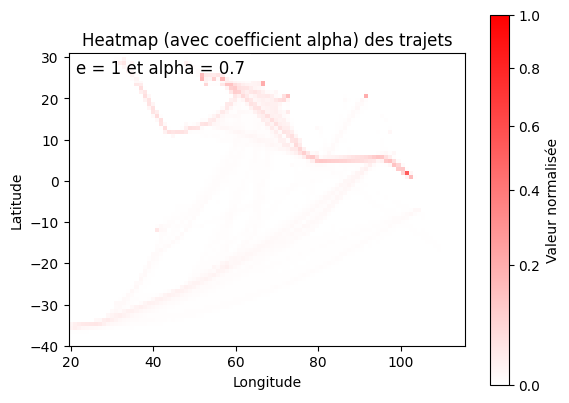

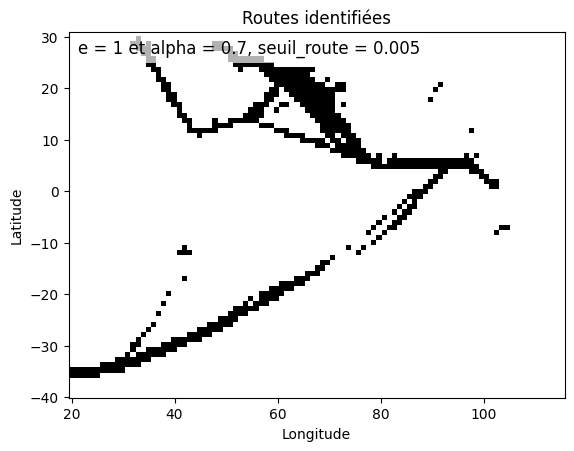

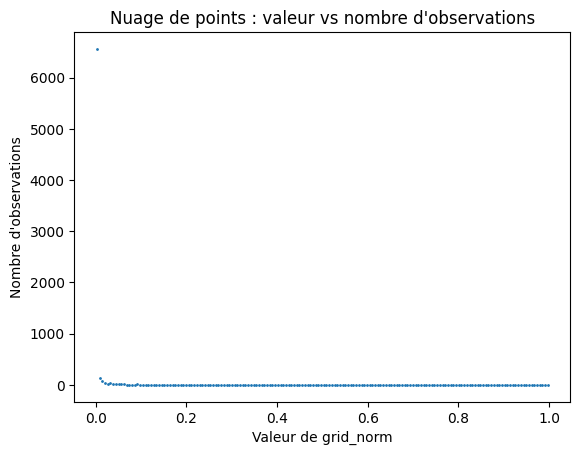

In [ ]:




  sssss

### Fusionner les scores pour avoir <= 2 cellules adjacentes de score non nul

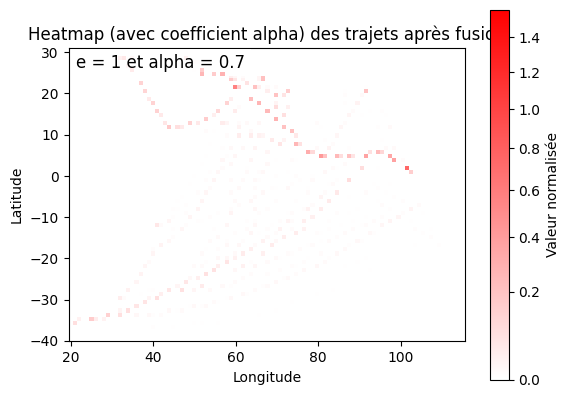

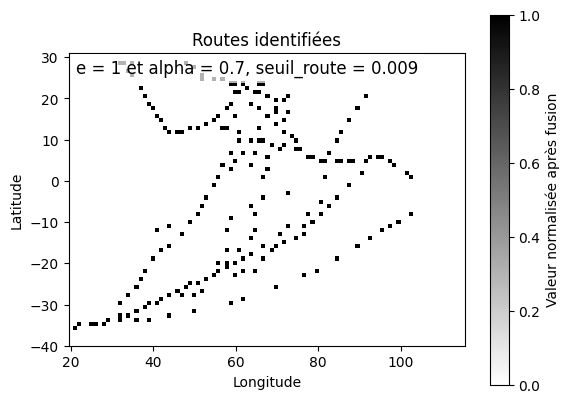

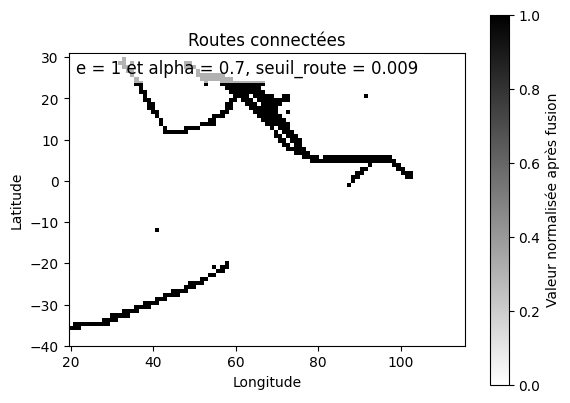

In [66]:
import numpy as np

def voisins_8(i, j, shape):
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            ni, nj = i + di, j + dj
            if 0 <= ni < shape[0] and 0 <= nj < shape[1]:
                yield ni, nj


def fusion_scores(grid):
    grid = grid.copy()
    changed = True

    while changed:
        changed = False

        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):

                if grid[i, j] == 0:
                    continue

                voisins = [
                    (ni, nj)
                    for ni, nj in voisins_8(i, j, grid.shape)
                    if grid[ni, nj] > 0
                ]

                if len(voisins) > 2:
                    # cellules impliquées : centre + voisins
                    cellules = [(i, j)] + voisins

                    # trier par score décroissant
                    cellules.sort(key=lambda x: grid[x], reverse=True)

                    # garder les 2 meilleures
                    a_garder = cellules[:2]
                    a_fusionner = cellules[2:]

                    # fusion vers la meilleure cellule
                    cible = a_garder[0]

                    for ci, cj in a_fusionner:
                        grid[cible] += grid[ci, cj]
                        grid[ci, cj] = 0
                        changed = True

    return grid

grid_fusionnee = fusion_scores(grid_norm)

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

#lat_min = i0 * e
#lat_max = (i0 + grid_norm.shape[0]) * e

#lon_min = j0 * e
#lon_max = (j0 + grid_norm.shape[1]) * e

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

cmap_white_red = mcolors.LinearSegmentedColormap.from_list(
    "white_red",
    ["white", "red"]
)

fig, ax = plt.subplots()

alpha = 0.7

im = ax.imshow(
    grid_fusionnee,
    cmap=cmap_white_red,
    norm=PowerNorm(gamma=alpha),
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ── 1) Affichage de la valeur de e sur la carte ──
ax.text(
    0.02, 0.98,            # position relative dans l'axe
    f"e = {e} et alpha = {alpha}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

# ── 2) Légende de couleur à droite ──
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Valeur normalisée")
plt.title("Heatmap (avec coefficient alpha) des trajets après fusion")
plt.show()


## extraction des routes 

seuil_route = 0.009

routes_0_1 = (grid_fusionnee > seuil_route).astype(int)

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

cmap_white_red = mcolors.LinearSegmentedColormap.from_list(
    "white_red",
    ["white", "black"]
)

fig, ax = plt.subplots()

im = ax.imshow(
    routes_0_1,
    cmap=cmap_white_red,
    #norm=PowerNorm(gamma=alpha),
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ── 1) Affichage de la valeur de e sur la carte ──
ax.text(
    0.02, 0.98,            # position relative dans l'axe
    f"e = {e} et alpha = {alpha}, seuil_route = {seuil_route}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

# ── 2) Légende de couleur à droite ──
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Valeur normalisée après fusion")
plt.title("Routes identifiées")
plt.show()

##faire en sorte d’ajouter que chaque cellule ayant + de voisines_minimum avec un score non nul dans un rayon de rayon_voisines puisse rejoindre ses voisines en passant par des cases de scores non nul sans passer par une case de score nul, et cela en passant par le moins de cases.
##Pour cela, il faut dupliquer le score de la cellule aux cellules à utiliser pour construire ce plus court chemin pour aller à la cellule la plus proche.
##et ainsi pour toutes les cellule vérifiant la condition du début.

def voisins_dans_rayon(i, j, shape, r):
    voisins = []
    for di in range(-r, r + 1):
        for dj in range(-r, r + 1):
            ni, nj = i + di, j + dj
            if (0 <= ni < shape[0] and 0 <= nj < shape[1]
                and not (di == 0 and dj == 0)):
                voisins.append((ni, nj))
    return voisins

from collections import deque

def chemin_existe(grid, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        i, j = queue.popleft()
        if (i, j) == goal:
            return True

        for di in [-1, 0, 1]:
            for dj in [-1, 0, 1]:
                if di == 0 and dj == 0:
                    continue
                ni, nj = i + di, j + dj
                if (0 <= ni < grid.shape[0]
                    and 0 <= nj < grid.shape[1]
                    and grid[ni, nj] > 0
                    and (ni, nj) not in visited):
                    visited.add((ni, nj))
                    queue.append((ni, nj))

    return False


def bresenham(i0, j0, i1, j1):
    points = []
    di = abs(i1 - i0)
    dj = abs(j1 - j0)
    si = 1 if i0 < i1 else -1
    sj = 1 if j0 < j1 else -1
    err = di - dj

    while True:
        points.append((i0, j0))
        if i0 == i1 and j0 == j1:
            break
        e2 = 2 * err
        if e2 > -dj:
            err -= dj
            i0 += si
        if e2 < di:
            err += di
            j0 += sj

    return points


def connecter_cellules(grid, voisines_minimum, rayon_voisines):
    grid = grid.copy()

    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):

            if grid[i, j] == 0:
                continue

            voisins = [
                (ni, nj) for ni, nj in voisins_dans_rayon(i, j, grid.shape, rayon_voisines)
                if grid[ni, nj] > 0
            ]

            if len(voisins) <= voisines_minimum:
                continue

            # cellule non nulle la plus proche
            voisins.sort(key=lambda x: abs(x[0]-i) + abs(x[1]-j))
            cible = voisins[0]

            if chemin_existe(grid, (i, j), cible):
                continue

            # créer le chemin minimal
            chemin = bresenham(i, j, cible[0], cible[1])

            for ci, cj in chemin:
                if grid[ci, cj] == 0:
                    grid[ci, cj] = grid[i, j]  # duplication du score

    return grid

grid_norm_connectee = connecter_cellules(
    grid_norm,
    voisines_minimum=3,
    rayon_voisines=5
)

routes_0_1_connectee = (grid_norm_connectee > seuil_route).astype(int)

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

cmap_white_red = mcolors.LinearSegmentedColormap.from_list(
    "white_red",
    ["white", "black"]
)

fig, ax = plt.subplots()

im = ax.imshow(
    routes_0_1_connectee,
    cmap=cmap_white_red,
    #norm=PowerNorm(gamma=alpha),
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# ── 1) Affichage de la valeur de e sur la carte ──
ax.text(
    0.02, 0.98,            # position relative dans l'axe
    f"e = {e} et alpha = {alpha}, seuil_route = {seuil_route}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)

# ── 2) Légende de couleur à droite ──
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Valeur normalisée après fusion")
plt.title("Routes connectées")
plt.show()


### 2ème vraie projection

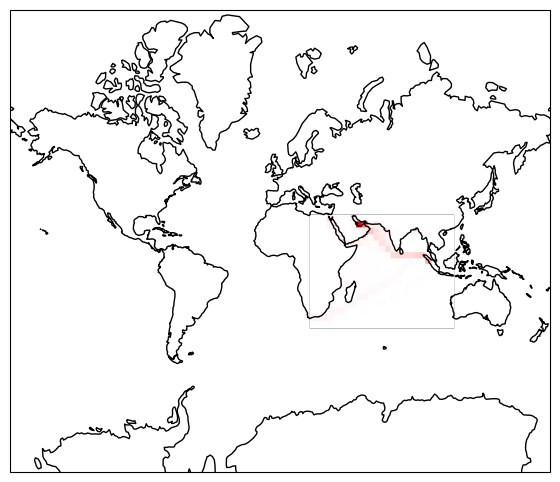

In [15]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Mercator())

ax.coastlines()
ax.set_global()

ax.imshow(
    grid_norm,
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    transform=ccrs.PlateCarree(),  # <- TES DONNÉES SONT EN LAT/LON
    cmap=cmap_white_red,
    #norm=PowerNorm(gamma=0.2)
)

plt.show()

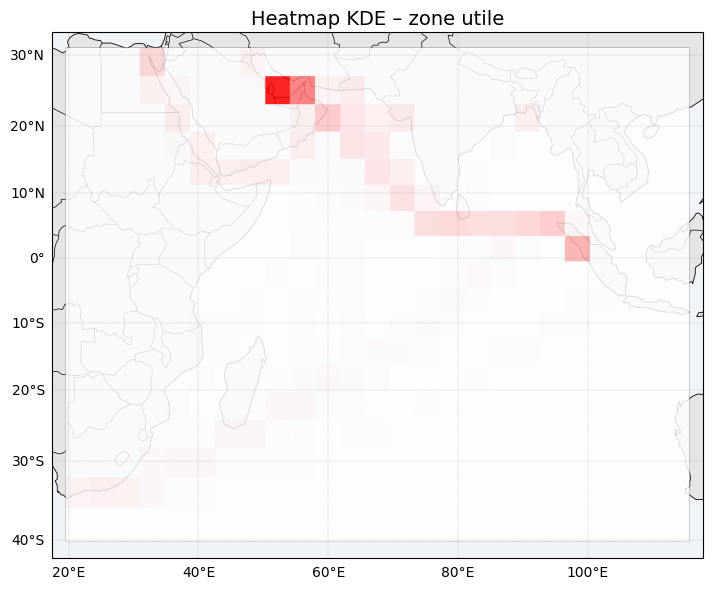

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import PowerNorm

# ==============================
# Paramètres d'affichage
# ==============================
margin = 2  # degrés autour de la zone utile

extent = [
    lon_min - margin,
    lon_max + margin,
    lat_min - margin,
    lat_max + margin
]

# ==============================
# Figure et projection
# ==============================
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Mercator())

# Emprise de la carte (IMPORTANT)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# ==============================
# Fond de carte
# ==============================
ax.add_feature(cfeature.OCEAN, facecolor="#f0f4f8", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#e5e5e5", zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

# ==============================
# Heatmap KDE (raster)
# ==============================
ax.imshow(
    grid_norm,                       # matrice normalisée [0,1]
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    transform=ccrs.PlateCarree(),    # données en lat/lon
    cmap=cmap_white_red,
    #norm=PowerNorm(gamma=0.2),
    alpha=0.85,
    zorder=2
)

# ==============================
# Grille & labels (optionnel)
# ==============================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# ==============================
# Titre
# ==============================
plt.title("Heatmap KDE – zone utile", fontsize=14)

plt.tight_layout()
plt.show()


### 3ème projection (Encore + précise, utile si grille irrégulière)

In [20]:
import numpy as np

lats = np.arange(lat_min, lat_max, e)
lons = np.arange(lon_min, lon_max, e)

Lon, Lat = np.meshgrid(lons, lats)

ax.pcolormesh(
    Lon,
    Lat,
    grid_norm,
    transform=ccrs.PlateCarree(),
    cmap=cmap_white_red,
    norm=PowerNorm(gamma=0.2),
    shading="auto"
)

## avec histogramme

In [ ]:
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
from matplotlib import colors

# -------------------------------
# 1️⃣ Charger les données (5 premières lignes)
# -------------------------------
df = pd.read_feather("data_indian_ocean.feather")

# -------------------------------
# 2️⃣ Convertir lat/lon en coordonnées approximatives en mètres
# -------------------------------
R = 6371000  # rayon terrestre en mètres

lat_rad = np.radians(df['latitude'].values)
lon_rad = np.radians(df['longitude'].values)

x = R * lon_rad * np.cos(np.mean(lat_rad))
y = R * lat_rad

# -------------------------------
# 3️⃣ Créer la grille 5 km x 5 km
# -------------------------------
grid_size = 5000  # 5 km

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

# S'assurer qu'il y a au moins 2 valeurs pour histogram2d
if xmin == xmax:
    xmax += grid_size
if ymin == ymax:
    ymax += grid_size

x_bins = np.arange(xmin, xmax + grid_size, grid_size)
y_bins = np.arange(ymin, ymax + grid_size, grid_size)

# -------------------------------
# 4️⃣ Compter les points dans chaque carré
# -------------------------------
H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

# Normaliser (éviter division par zéro)
if H.max() > 0:
    score = H / H.max()
else:
    score = H

# -------------------------------
# 5️⃣ Créer la carte Folium
# -------------------------------
map_center = [df['latitude'].mean(), df['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=6)

cmap = plt.cm.hot
norm = colors.Normalize(vmin=0, vmax=1)

for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        if score[i, j] > 0:
            x0, x1 = xedges[i], xedges[i+1]
            y0, y1 = yedges[j], yedges[j+1]

            # Convertir en lat/lon
            lat0 = np.degrees(y0 / R)
            lat1 = np.degrees(y1 / R)
            lon0 = np.degrees(x0 / (R * np.cos(np.mean(lat_rad))))
            lon1 = np.degrees(x1 / (R * np.cos(np.mean(lat_rad))))

            color = colors.rgb2hex(cmap(norm(score[i,j])))
            folium.Rectangle(
                bounds=[[lat0, lon0], [lat1, lon1]],
                color=None,
                fill=True,
                fillColor=color,
                fillOpacity=0.7
            ).add_to(m)

m


In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# -------------------------------
# 1️⃣ Charger les 5 premières lignes
# -------------------------------
df = pd.read_feather("data_indian_ocean.feather").head(50000)

# -------------------------------
# 2️⃣ Créer la carte centrée sur les points
# -------------------------------
map_center = [df['latitude'].mean(), df['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=4)

# -------------------------------
# 3️⃣ Préparer les points pour la heatmap
# -------------------------------
# Folium HeatMap attend [[lat, lon, weight], ...]
# Ici, chaque point vaut 1 (on compte chaque passage)
heat_data = [[row['latitude'], row['longitude'], 1] for _, row in df.iterrows()]

# -------------------------------
# 4️⃣ Normaliser le poids des points entre 0 et 1
# -------------------------------
max_weight = max([w for _, _, w in heat_data])
if max_weight > 0:
    heat_data = [[lat, lon, w/max_weight] for lat, lon, w in heat_data]

# -------------------------------
# 5️⃣ Ajouter la heatmap sur la carte
# -------------------------------
HeatMap(heat_data, radius=15).add_to(m)  # radius en pixels

# -------------------------------
# 6️⃣ Afficher la carte
# -------------------------------



## Drafts

In [ ]:
import pandas as pd
import folium

# Charger les données
df = pd.read_feather("data_indian_ocean.feather")

# Convertir le timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Filtrer sur le 1er janvier 2015
df_jan1 = df[df['timestamp'].dt.date == pd.to_datetime("2015-01-01").date()]

# Prendre le premier navire (premier mmsi)
first_mmsi = df_jan1['mmsi'].iloc[0]
df_ship = df_jan1[df_jan1['mmsi'] == first_mmsi].sort_values('timestamp')

# Créer la carte centrée sur ce navire
map_center = [df_ship['latitude'].mean(), df_ship['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=6)

# Ajouter la trajectoire
trajet = list(zip(df_ship['latitude'], df_ship['longitude']))
folium.PolyLine(trajet, color='blue', weight=2.5, opacity=0.8).add_to(m)

# Points de départ et d'arrivée
folium.Marker(trajet[0], popup="Start", icon=folium.Icon(color='green')).add_to(m)
folium.Marker(trajet[-1], popup="End", icon=folium.Icon(color='red')).add_to(m)

# Afficher la carte directement dans Python (Notebook ou VS Code Interactive)
m
